# 02. Elastic cross sections from a learned partial-wave model

This notebook extends the single-wavefunction calculation to neutron
elastic scattering from $^{40}\mathrm{Ca}$ at
$E_{\mathrm{lab}}=14.1$ MeV. The independent full-order model (FOM)
solves every spin-orbit partial-wave channel for a complex Woods--Saxon
optical potential. One learned reduced-order model (LROM) is then trained
per channel, and their predicted $S$ matrices are assembled into the
differential cross section.

The study uses $\ell=0,\ldots,10$, 500 training potentials, 100 held-out
potentials, and five reduced configurations. ROSE remains outside the
LROM training pipeline and is trained independently at the same reduced
basis and empirical-interpolation sizes.

The implementation follows the package boundaries directly:

- `lrom.physics` defines kinematics and optical potentials;
- `lrom.fom` solves radial equations and extracts channel $S$ matrices;
- `lrom.observables` assembles amplitudes and cross sections;
- `lrom.reduced` builds and evaluates the learned reduced models; and
- `lrom.diagnostics` defines comparison metrics.

## Observable and error measures

For spin-$1/2$ scattering from a spin-zero target, the two scattering
amplitudes are assembled from the $j=\ell\pm\tfrac12$ channel matrices,

$$
A(\theta)=\frac{1}{2ik}\sum_{\ell=0}^{\ell_{\max}}
\left[(\ell+1)(S_\ell^+-1)+\ell(S_\ell^--1)\right]
P_\ell(\cos\theta),
$$

$$
B(\theta)=\frac{1}{2ik}\sum_{\ell=1}^{\ell_{\max}}
(S_\ell^+-S_\ell^-)P_\ell^1(\cos\theta),\qquad
\frac{d\sigma}{d\Omega}=|A|^2+|B|^2.
$$

The least-squares (LS) result projects each exact FOM wavefunction into
the same centered basis and therefore measures the basis-truncation floor.
LROM predicts the reduced coordinates from potential values. The final
computational-accuracy-versus-time (CAT) plot follows Eq. (30) of the ROSE
paper and assigns each held-out parameter point the maximum pointwise
relative cross-section error over $1^\circ\leq\theta\leq179^\circ$.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0,str(ROOT))
os.environ.setdefault('MPLCONFIGDIR',str(ROOT/'.matplotlib-cache'))

import hashlib
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import LogFormatterMathtext

from lrom import (
    BasisConfig, InputSpace, MaxVol, ScatteringLROM, ScatteringProblem, get_runtime,
)
from lrom.physics import FULL_PARAMETER_NAMES, real_woods_saxon
from lrom.fom import s_matrices_from_scaled_wavefunctions
from lrom.observables import assemble_elastic_cross_sections
from lrom.diagnostics import pointwise_relative_error

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"LS": "#2457E6", "LROM": "#E6AB02", "ROSE": "#EF4423"}
PARAMETER_CMAP = LinearSegmentedColormap.from_list(
    "parameter", ["#2446A8", "#7776D4", "#C66EC5", "#F15A9D"]
)
LOG_FORMATTER = LogFormatterMathtext(base=10)

SEED = 1204
L_MAX = 10
N_TRAIN, N_TEST = 500, 100
CONFIGURATIONS = ((4, 8), (6, 12), (6, 16), (8, 16), (12, 16))
DEFAULT_CONFIGURATION = (6, 16)
MINIMUM_PREDICTOR_S = 0.1
TIMING_REPEATS = 3
TIMING_INNER_LOOPS = 20
ERROR_DENOMINATOR_FLOOR = 1.0e-12
PLOTTING_FLOOR = 1.0e-12
angles = np.arange(1.0, 180.0)

problem = ScatteringProblem(
    potential="full_woods_saxon", target_a=40, target_z=20,
    lab_energy=14.1, l_max=L_MAX, mesh_points=800,
    target_binding_energy=342.052184,
)
system = problem.system()
s_mesh = system.s_mesh
radius = system.radius
omega0 = problem.reference_omega
input_space = InputSpace(
    continuous={
        name: (0.80 * value, 1.20 * value)
        for name, value in zip(FULL_PARAMETER_NAMES, omega0)
    },
    fixed={"E": 14.1, "A": 40, "Z": 20},
)
train_samples = input_space.sample(N_TRAIN, SEED)
test_samples = input_space.sample(N_TEST, SEED + 1)
input_space.validate(train_samples + test_samples)
train_rows = np.asarray([[sample[name] for name in FULL_PARAMETER_NAMES]
                         for sample in train_samples])
test_rows = np.asarray([[sample[name] for name in FULL_PARAMETER_NAMES]
                        for sample in test_samples])
channels = problem.channels

pd.Series({
    "target": "40Ca", "projectile": "neutron",
    "E_lab [MeV]": system.lab_energy, "E_cm [MeV]": system.com_energy,
    "wave number [fm^-1]": system.wave_number,
    "optical parameters": len(omega0), "partial-wave channels": len(channels),
    "training potentials": N_TRAIN, "held-out potentials": N_TEST,
    "scaled mesh points": len(s_mesh), "s_max": s_mesh[-1],
    "matching s": system.matching_s, "equivalent r_max [fm]": radius[-1],
}, name="calculation")

BACKEND=os.getenv("LROM_BACKEND","cpu")
PRECISION=os.getenv("LROM_PRECISION","double")
runtime=get_runtime(BACKEND,PRECISION)
print(f"online runtime: {runtime.name} on {runtime.device} ({runtime.precision})")


online runtime: numpy-cpu on CPU (double)


## 1. Independent full-order database

The FOM solves the dimensionless equation on the common coordinate
$s=kr$, with operator potential $V(s/k)/E_{\rm cm}$. For each $\ell$ it
begins only where the regular solution $C_\ell s^{\ell+1}$ reaches the
numerical threshold, using its positive derivative as the shooting
convention. For $\ell>0$, the two spin-orbit
branches use factors $\ell$ and $-(\ell+1)$. Every training and held-out
wavefunction and $S$ matrix is generated before fitting a reduced model.

In [2]:
start = time.perf_counter()
training_data = problem.generate_training_data(train_samples)
test_data = problem.generate_training_data(test_samples)
fom_seconds = time.perf_counter() - start
print(
    f"Generated {len(channels) * (N_TRAIN + N_TEST + 1):,} "
    f"channel solutions in {fom_seconds:.2f} s"
)

Generated 12,621 channel solutions in 9.94 s


In [3]:
fom_train_xs = assemble_elastic_cross_sections(
    training_data.s_matrices,
    angles, system.wave_number,
)
fom_test_xs = assemble_elastic_cross_sections(
    test_data.s_matrices,
    angles, system.wave_number,
)
print(
    f"Held-out cross-section array: {fom_test_xs.shape}; "
    f"range = {fom_test_xs.min():.3e}--{fom_test_xs.max():.3e} mb/sr"
)

# Time the complete parameter-to-observable calculation after one warm-up.
problem.cross_section(test_samples[0], angles)
independent_fom_seconds = np.empty(N_TEST)
for index, sample in enumerate(test_samples):
    repeats = []
    for _ in range(TIMING_REPEATS):
        tic = time.perf_counter_ns()
        problem.cross_section(sample, angles)
        repeats.append((time.perf_counter_ns() - tic) / 1.0e9)
    independent_fom_seconds[index] = min(repeats)
print(
    f"Independent FOM median online time: "
    f"{np.median(independent_fom_seconds):.3e} s per cross section"
)

Held-out cross-section array: (100, 179); range = 4.967e-02--5.426e+03 mb/sr


Independent FOM median online time: 1.554e-02 s per cross section


## 2. Partial-wave reduced models

Each spin channel receives a centered wavefunction basis and its own
learned implicit coordinate equation. The configurations below vary the
wavefunction-basis size $N_\phi$ and number of potential predictors $N_p$
independently. Predictor selection is performed directly on the common
scaled coordinate $s=kr$, with $s\geq0.1$. This avoids the formal
near-origin $1/r$ spin--orbit structure while retaining essentially the
complete physical interaction region.

In [4]:
fit_capacity = pd.DataFrame([
    {
        r"$N_\phi$": basis_size,
        r"$N_p$": predictor_count,
        "complex coefficients per equation row": (
            predictor_count * (basis_size + 1)
        ),
        "training samples": N_TRAIN,
        "samples per coefficient": (
            N_TRAIN / (predictor_count * (basis_size + 1))
        ),
    }
    for basis_size, predictor_count in CONFIGURATIONS
])
fit_capacity

,$N_\phi$,$N_p$,complex coefficients per equation row,training samples,samples per coefficient
0,4,8,40,500,12.500000
1,6,12,84,500,5.952381
2,6,16,112,500,4.464286
3,8,16,144,500,3.472222
4,12,16,208,500,2.403846


Each row of the learned implicit equation contains

$$
N_{\mathrm{fit,row}}=N_p(N_\phi+1)
$$

fitted complex coefficients. All displayed configurations have more than
two training samples per coefficient. The package also checks this count
during training and warns automatically when the sampling margin becomes
small or the regression is underdetermined.

In [5]:
results = {}
for basis_size, predictor_count in CONFIGURATIONS:
    configuration = (basis_size, predictor_count)
    start = time.perf_counter()
    emulator = ScatteringLROM(
        problem,
        BasisConfig(size=basis_size),
        MaxVol(count=predictor_count, minimum_s=MINIMUM_PREDICTOR_S),
    ).train(training_data)
    models = {
        key: channel_model.learned
        for key, channel_model in emulator.channel_models.items()
    }
    ls_train_s, ls_test_s = {}, {}

    # LS projection is an offline diagnostic of basis truncation. Unlike
    # the online LROM path, it intentionally has access to exact FOM waves.
    for key, model in models.items():
        ell, spin = key
        ls_train_wave = model.basis.reconstruct(
            model.basis.project(training_data.wavefunctions[key])
        )
        ls_test_wave = model.basis.reconstruct(
            model.basis.project(test_data.wavefunctions[key])
        )
        ls_train_s[key] = s_matrices_from_scaled_wavefunctions(
            s_mesh, ls_train_wave, ell, problem.matching_s
        )
        ls_test_s[key] = s_matrices_from_scaled_wavefunctions(
            s_mesh, ls_test_wave, ell, problem.matching_s
        )

    # Calculate cross sections using functions defined inside lrom. The
    # online calculation evaluates the potential only at the selected
    # scaled coordinates, solves all channel equations in one batch, and
    # obtains phi(s0) and dphi/ds(s0) directly from reduced coordinates.
    # It therefore never reconstructs a full radial wavefunction.
    lrom_train_xs = np.asarray([
        emulator.cross_section(sample, angles) for sample in train_samples
    ])
    lrom_test_xs = np.asarray([
        emulator.cross_section(sample, angles) for sample in test_samples
    ])
    ls_train_xs = assemble_elastic_cross_sections(
        ls_train_s, angles, system.wave_number
    )
    ls_test_xs = assemble_elastic_cross_sections(
        ls_test_s, angles, system.wave_number
    )

    # The online timing includes potential evaluation, all reduced solves,
    # S-matrix extraction, and assembly of the final cross section.
    online_seconds = np.empty(N_TEST)
    emulator.cross_section(test_samples[0], angles)  # warm-up
    for index, sample in enumerate(test_samples):
        repeats = []
        for _ in range(TIMING_REPEATS):
            tic = time.perf_counter_ns()
            for _inner in range(TIMING_INNER_LOOPS):
                emulator.cross_section(sample, angles)
            repeats.append(
                (time.perf_counter_ns() - tic)
                / (1.0e9 * TIMING_INNER_LOOPS)
            )
        online_seconds[index] = min(repeats)

    result = {
        "emulator": emulator,
        "models": models,
        "fit_and_evaluate_seconds": time.perf_counter() - start,
        "online_seconds": online_seconds,
        "LROM": {"train_xs": lrom_train_xs, "test_xs": lrom_test_xs},
        "LS": {"train_xs": ls_train_xs, "test_xs": ls_test_xs},
    }
    for method in ("LS", "LROM"):
        for split, reference in (("train", fom_train_xs), ("test", fom_test_xs)):
            errors = pointwise_relative_error(
                result[method][f"{split}_xs"], reference,
                denominator_floor=ERROR_DENOMINATOR_FLOOR,
            )
            result[method][f"{split}_median_error"] = np.median(errors, axis=1)
            result[method][f"{split}_maximum_error"] = np.max(errors, axis=1)
    results[configuration] = result
default_emulator = results[DEFAULT_CONFIGURATION]["emulator"]

### Potential family and selected predictor locations

The upper panels show the scaled nuclear operator that actually enters the
LROM, $V(s/k)/E_{\rm cm}$; no centrifugal term is included. The
Woods--Saxon spin-orbit form contains an explicit $1/r$ factor, so curves
are drawn only where $s\geq0.1$, while the displayed scaled-coordinate axes
begin at $s=0$. Vertical limits are determined from the drawn curves.

Dashed curves show the volume contribution alone.  On the real side, its
separation from the total central curve is the real spin--orbit term.  On
the imaginary side, the separation is the absorptive surface term. The
faint blue and red curves are twelve representative scaled-potential rows
from the common 500-potential training set. Gold points on the reference
operator show the default $(N_\phi,N_p)=(6,16)$ selection for the
$\ell=2$, $j=\ell+1/2$ channel. The lower panel compares
the selected scaled coordinates for all five configurations.

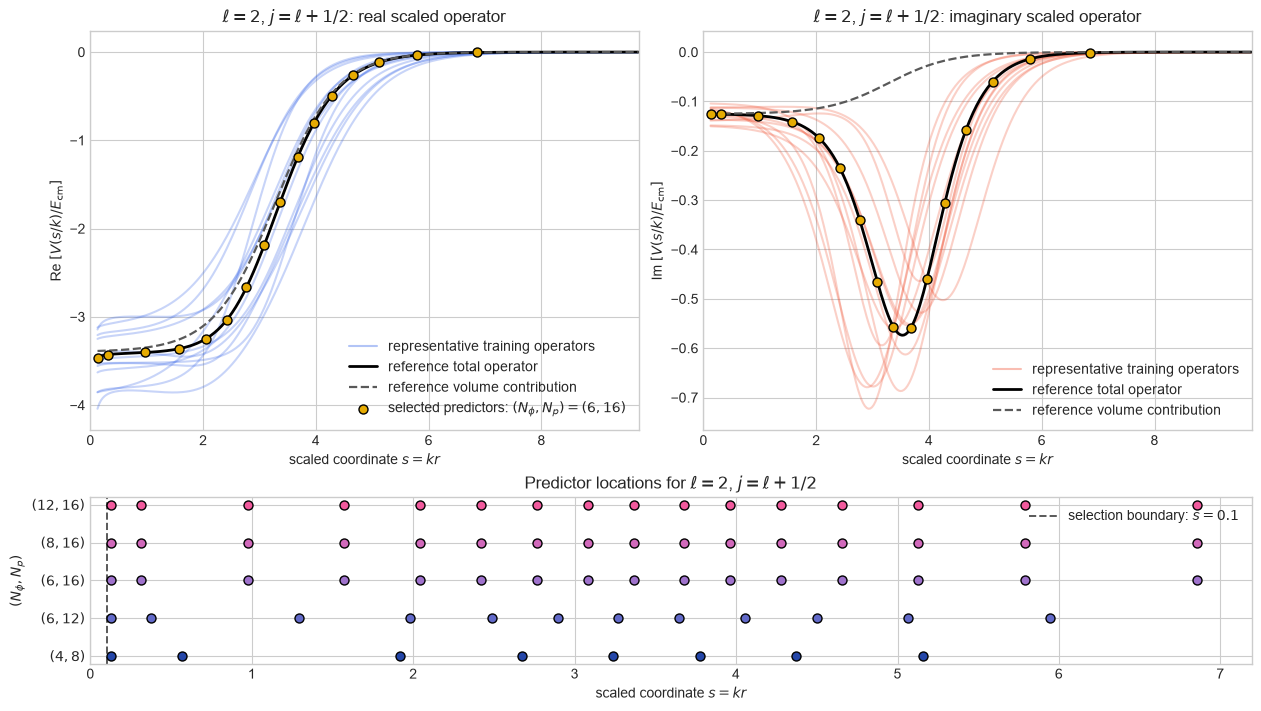

In [6]:
key = (2, 2.0)
model = default_emulator.channel_models[key].learned
maximum_plot_s = min(float(s_mesh[-1]), 12.0 * system.wave_number)
plot_mask = (s_mesh >= MINIMUM_PREDICTOR_S) & (s_mesh <= maximum_plot_s)
plot_s = s_mesh[plot_mask]

fig = plt.figure(figsize=(12.5, 7.0), layout="constrained")
grid = fig.add_gridspec(2, 2, height_ratios=(3.0, 1.25))
axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])]
predictor_axis = fig.add_subplot(grid[1, :])
sample_indices = np.linspace(0, N_TRAIN - 1, 12, dtype=int)
for index in sample_indices:
    scaled_potential = training_data.potentials[key][index]
    axes[0].plot(plot_s, scaled_potential.real[plot_mask],
                 color="#2457E6", alpha=0.25)
    axes[1].plot(plot_s, scaled_potential.imag[plot_mask],
                 color="#EF4423", alpha=0.25)
axes[0].plot([], [], color="#2457E6", alpha=0.35,
             label="representative training operators")
axes[1].plot([], [], color="#EF4423", alpha=0.35,
             label="representative training operators")

reference = training_data.reference_potentials[key]
volume_shape = real_woods_saxon(
    radius, np.array([1.0, omega0[4], omega0[7]])
)
reference_volume = (
    (omega0[0] + 1j * omega0[1]) * volume_shape / system.com_energy
)
predictor_s = model.selected_coordinates
axes[0].plot(plot_s, reference.real[plot_mask], color="black", lw=2,
             label="reference total operator")
axes[1].plot(plot_s, reference.imag[plot_mask], color="black", lw=2,
             label="reference total operator")
axes[0].plot(plot_s, reference_volume.real[plot_mask], "--", color="0.35",
             lw=1.6, label="reference volume contribution")
axes[1].plot(plot_s, reference_volume.imag[plot_mask], "--", color="0.35",
             lw=1.6, label="reference volume contribution")
axes[0].scatter(
    predictor_s,
    np.interp(predictor_s, s_mesh, reference.real),
    color=COLORS["LROM"], edgecolor="black", s=42,
    label=r"selected predictors: $(N_\phi,N_p)=(6,16)$", zorder=5,
)
axes[1].scatter(
    predictor_s,
    np.interp(predictor_s, s_mesh, reference.imag),
    color=COLORS["LROM"], edgecolor="black", s=42, zorder=5,
)
axes[0].set(title=r"$\ell=2$, $j=\ell+1/2$: real scaled operator",
            xlabel=r"scaled coordinate $s=kr$",
            ylabel=r"Re $[V(s/k)/E_{\rm cm}]$",
            xlim=(0.0, maximum_plot_s))
axes[1].set(title=r"$\ell=2$, $j=\ell+1/2$: imaginary scaled operator",
            xlabel=r"scaled coordinate $s=kr$",
            ylabel=r"Im $[V(s/k)/E_{\rm cm}]$",
            xlim=(0.0, maximum_plot_s))
real_visible = np.concatenate([
    training_data.potentials[key][index].real[plot_mask]
    for index in sample_indices
] + [reference.real[plot_mask], reference_volume.real[plot_mask]])
imag_visible = np.concatenate([
    training_data.potentials[key][index].imag[plot_mask]
    for index in sample_indices
] + [reference.imag[plot_mask], reference_volume.imag[plot_mask]])
for axis, values in zip(axes, [real_visible, imag_visible]):
    span = values.max() - values.min()
    axis.set_ylim(values.min() - 0.06 * span, values.max() + 0.06 * span)
axes[0].legend()
axes[1].legend()
for row, configuration in enumerate(CONFIGURATIONS):
    selected_s = results[configuration]["emulator"].channel_models[key].learned.selected_coordinates
    predictor_axis.scatter(selected_s, np.full(len(selected_s), row), s=42,
                           color=PARAMETER_CMAP(row / (len(CONFIGURATIONS) - 1)),
                           edgecolor="black", zorder=4)
predictor_axis.axvline(MINIMUM_PREDICTOR_S, color="0.35", ls="--", lw=1.4,
                       label=rf"selection boundary: $s={MINIMUM_PREDICTOR_S}$")
predictor_axis.set_yticks(range(len(CONFIGURATIONS)),
                          [rf"$({nphi},{npred})$" for nphi, npred in CONFIGURATIONS])
predictor_axis.set(xlabel=r"scaled coordinate $s=kr$",
                   ylabel=r"$(N_\phi,N_p)$",
                   title=r"Predictor locations for $\ell=2$, $j=\ell+1/2$")
predictor_axis.set_xlim(left=0.0)
predictor_axis.legend(loc="upper right")
assert all(
    np.all(results[configuration]["emulator"].channel_models[key].learned.selected_coordinates
           >= MINIMUM_PREDICTOR_S)
    for configuration in CONFIGURATIONS
)
plt.show()

### Independent ROSE reduced models

ROSE is now trained at the same five $(N_\phi,N_{\rm EIM})$
configurations. Its reduced cross sections are compared with ROSE's own
high-fidelity solver, while LS and LROM remain compared with the Numerov
FOM that generated their bases. This keeps the reduced-model errors
separate from the smaller difference between the two independent FOMs.

In [7]:
import io
from contextlib import redirect_stderr, redirect_stdout
import rose  # explicit optional dependency used only by this benchmark
from benchmarks.rose import (
    exact_cross_section_evaluator, reduced_cross_section_emulators,
)

cache_directory = Path("benchmarks") / "cache"
cache_directory.mkdir(parents=True, exist_ok=True)
cache_metadata = np.ascontiguousarray(np.vstack([train_rows, test_rows])).tobytes()
cache_metadata += repr((CONFIGURATIONS, L_MAX, tuple(angles))).encode()
cache_key = hashlib.sha256(cache_metadata).hexdigest()[:16]
rose_cache = cache_directory / f"rose_notebook02_{cache_key}.npz"

rose_results = {}
if rose_cache.exists():
    cached = np.load(rose_cache)
    rose_fom_train_xs = cached["fom_train_xs"]
    rose_fom_test_xs = cached["fom_test_xs"]
    rose_fom_seconds = cached["fom_seconds"]
    for configuration in CONFIGURATIONS:
        tag = f"{configuration[0]}_{configuration[1]}"
        rose_results[configuration] = {
            "train_xs": cached[f"train_xs_{tag}"],
            "test_xs": cached[f"test_xs_{tag}"],
            "online_seconds": cached[f"online_seconds_{tag}"],
        }
    print(f"Loaded cached ROSE results from {rose_cache}")
else:
    rose_fom = exact_cross_section_evaluator(
        radius, angles, l_max=L_MAX, parameter_count=len(omega0),
        target=(40, 20), projectile=(1, 0), lab_energy=14.1,
    )
    rose_fom_train_xs = np.asarray([rose_fom.evaluate(row) for row in train_rows])
    rose_fom_test_xs = np.asarray([rose_fom.evaluate(row) for row in test_rows])

    # ROSE prints progress bars while constructing each partial-wave basis;
    # suppress them in the saved collaborator-facing notebook.
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        rose_models = reduced_cross_section_emulators(
            radius, angles, train_rows, CONFIGURATIONS,
            l_max=L_MAX, target=(40, 20), projectile=(1, 0), lab_energy=14.1,
        )

    for configuration in CONFIGURATIONS:
        train_xs = np.asarray([
            rose_models.evaluate(configuration, row) for row in train_rows
        ])
        test_xs = np.asarray([
            rose_models.evaluate(configuration, row) for row in test_rows
        ])
        online_seconds = np.empty(N_TEST)
        rose_models.evaluate(configuration, test_rows[0])
        for index, row in enumerate(test_rows):
            repeats = []
            for _ in range(TIMING_REPEATS):
                tic = time.perf_counter_ns()
                for _inner in range(TIMING_INNER_LOOPS):
                    rose_models.evaluate(configuration, row)
                repeats.append(
                    (time.perf_counter_ns() - tic)
                    / (1.0e9 * TIMING_INNER_LOOPS)
                )
            online_seconds[index] = min(repeats)
        rose_results[configuration] = {
            "train_xs": train_xs,
            "test_xs": test_xs,
            "online_seconds": online_seconds,
        }

    rose_fom.evaluate(test_rows[0])
    rose_fom_seconds = np.empty(N_TEST)
    for index, row in enumerate(test_rows):
        repeats = []
        for _ in range(TIMING_REPEATS):
            tic = time.perf_counter_ns()
            rose_fom.evaluate(row)
            repeats.append((time.perf_counter_ns() - tic) / 1.0e9)
        rose_fom_seconds[index] = min(repeats)
    cache_values = {
        "fom_train_xs": rose_fom_train_xs,
        "fom_test_xs": rose_fom_test_xs,
        "fom_seconds": rose_fom_seconds,
    }
    for configuration, values in rose_results.items():
        tag = f"{configuration[0]}_{configuration[1]}"
        cache_values[f"train_xs_{tag}"] = values["train_xs"]
        cache_values[f"test_xs_{tag}"] = values["test_xs"]
        cache_values[f"online_seconds_{tag}"] = values["online_seconds"]
    np.savez_compressed(rose_cache, **cache_values)
    print(f"Saved reusable ROSE results to {rose_cache}")

for configuration in CONFIGURATIONS:
    for split, reference in (("train", rose_fom_train_xs),
                             ("test", rose_fom_test_xs)):
        errors = pointwise_relative_error(
            rose_results[configuration][f"{split}_xs"], reference,
            denominator_floor=ERROR_DENOMINATOR_FLOOR,
        )
        rose_results[configuration][f"{split}_median_error"] = np.median(errors, axis=1)
        rose_results[configuration][f"{split}_maximum_error"] = np.max(errors, axis=1)

comparison_summary = pd.DataFrame([
    {
        "configuration": configuration,
        "LROM median held-out error": np.median(
            results[configuration]["LROM"]["test_median_error"]
        ),
        "LROM mean online time [ms]": 1.0e3 * np.mean(
            results[configuration]["online_seconds"]
        ),
        "ROSE median held-out error": np.median(
            rose_results[configuration]["test_median_error"]
        ),
        "ROSE mean online time [ms]": 1.0e3 * np.mean(
            rose_results[configuration]["online_seconds"]
        ),
    }
    for configuration in CONFIGURATIONS
]).set_index("configuration")
comparison_summary

Loaded cached ROSE results from benchmarks\cache\rose_notebook02_c15714dd84e007f6.npz


,LROM median held-out error,LROM mean online time [ms],ROSE median held-out error,ROSE mean online time [ms]
configuration,,,,
"(4, 8)",0.007462,0.061566,0.033752,0.480781
"(6, 12)",0.000415,0.084941,0.000914,0.476032
"(6, 16)",0.000209,0.083022,0.000438,0.509392
"(8, 16)",0.000046,0.101408,0.000154,0.528822
"(12, 16)",0.000021,0.139176,0.000157,0.581754


### Cross-section error distributions

Each violin contains one error value per optical potential: the median
pointwise relative error over angle. Dark left halves are training cases
and pale right halves are held-out cases. Diamonds mark distribution
medians. Mean online evaluation times are reported below each reduced
configuration. The LS panel isolates the wavefunction-basis truncation
floor and therefore depends only on $N_\phi$.

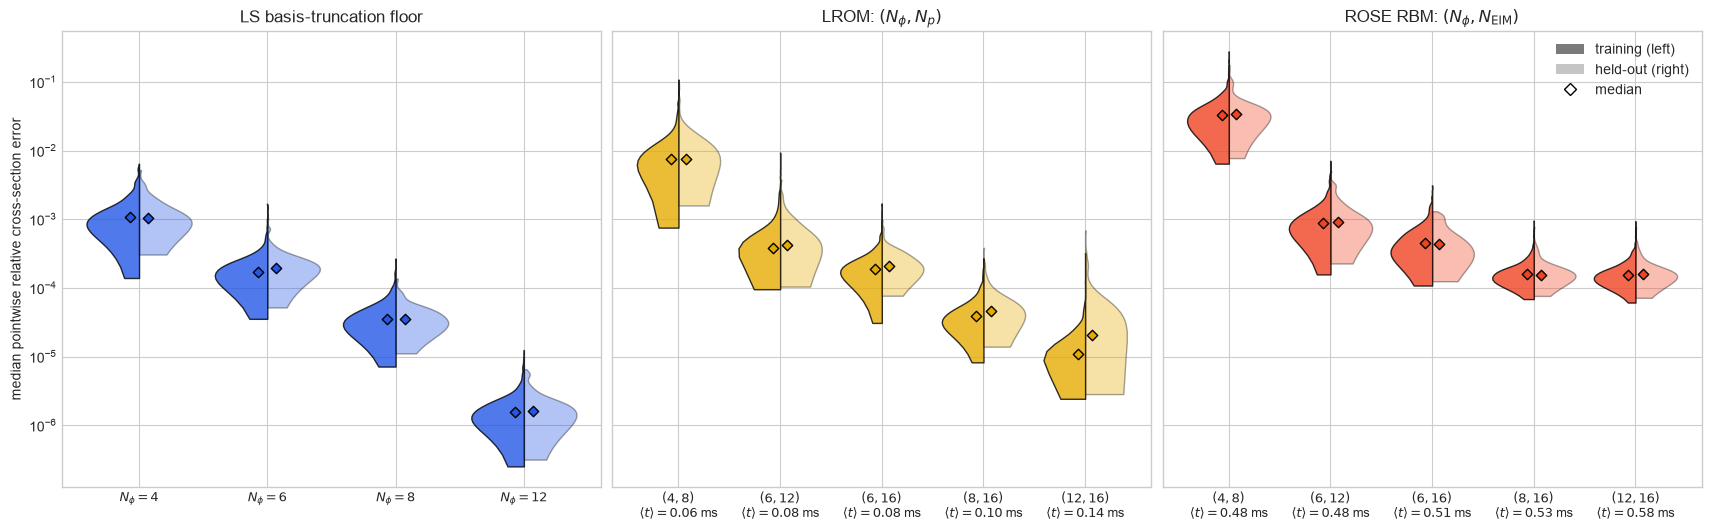

In [8]:
def split_violins(axis, train_values, test_values, positions, color):
    '''Draw training on the left and held-out values on the right.'''
    left = axis.violinplot(train_values, positions=positions, widths=0.82,
                           showmedians=False, showextrema=False)
    right = axis.violinplot(test_values, positions=positions, widths=0.82,
                            showmedians=False, showextrema=False)
    for center, body in zip(positions, left["bodies"]):
        body.get_paths()[0].vertices[:, 0] = np.minimum(
            body.get_paths()[0].vertices[:, 0], center
        )
        body.set_facecolor(color); body.set_edgecolor("black"); body.set_alpha(0.80)
    for center, body in zip(positions, right["bodies"]):
        body.get_paths()[0].vertices[:, 0] = np.maximum(
            body.get_paths()[0].vertices[:, 0], center
        )
        body.set_facecolor(color); body.set_edgecolor("black"); body.set_alpha(0.35)
    for center, train, test in zip(positions, train_values, test_values):
        axis.scatter(center - 0.07, np.median(train), marker="D", s=28,
                     color=color, edgecolor="black", zorder=6)
        axis.scatter(center + 0.07, np.median(test), marker="D", s=28,
                     color=color, edgecolor="black", zorder=6)

fig, axes = plt.subplots(
    1, 3, figsize=(17.0, 5.2), sharey=True, layout="constrained"
)
unique_basis_sizes = tuple(dict.fromkeys(nphi for nphi, _npred in CONFIGURATIONS))
basis_positions = np.arange(1, len(unique_basis_sizes) + 1)
representative_configuration = {
    nphi: next(config for config in CONFIGURATIONS if config[0] == nphi)
    for nphi in unique_basis_sizes
}
split_violins(
    axes[0],
    [np.maximum(results[representative_configuration[n]]["LS"]["train_median_error"], PLOTTING_FLOOR)
     for n in unique_basis_sizes],
    [np.maximum(results[representative_configuration[n]]["LS"]["test_median_error"], PLOTTING_FLOOR)
     for n in unique_basis_sizes],
    basis_positions, COLORS["LS"],
)
axes[0].set_xticks(basis_positions, [rf"$N_\phi={n}$" for n in unique_basis_sizes])
axes[0].set_title("LS basis-truncation floor")

positions = np.arange(1, len(CONFIGURATIONS) + 1)
lrom_train = [np.maximum(results[c]["LROM"]["train_median_error"], PLOTTING_FLOOR)
              for c in CONFIGURATIONS]
lrom_test = [np.maximum(results[c]["LROM"]["test_median_error"], PLOTTING_FLOOR)
             for c in CONFIGURATIONS]
rose_train = [np.maximum(rose_results[c]["train_median_error"], PLOTTING_FLOOR)
              for c in CONFIGURATIONS]
rose_test = [np.maximum(rose_results[c]["test_median_error"], PLOTTING_FLOOR)
             for c in CONFIGURATIONS]
split_violins(axes[1], lrom_train, lrom_test, positions, COLORS["LROM"])
split_violins(axes[2], rose_train, rose_test, positions, COLORS["ROSE"])

lrom_labels = [
    rf"$({c[0]},{c[1]})$" + "\n" + rf"$\langle t\rangle={1e3*np.mean(results[c]['online_seconds']):.2f}$ ms"
    for c in CONFIGURATIONS
]
rose_labels = [
    rf"$({c[0]},{c[1]})$" + "\n" + rf"$\langle t\rangle={1e3*np.mean(rose_results[c]['online_seconds']):.2f}$ ms"
    for c in CONFIGURATIONS
]
axes[1].set_xticks(positions, lrom_labels)
axes[2].set_xticks(positions, rose_labels)
axes[1].set_title(r"LROM: $(N_\phi,N_p)$")
axes[2].set_title(r"ROSE RBM: $(N_\phi,N_{\rm EIM})$")
for axis in axes:
    axis.set_yscale("log", nonpositive="clip")
    axis.yaxis.set_major_formatter(LOG_FORMATTER)
    axis.tick_params(axis="x", labelsize=9)
axes[0].set_ylabel("median pointwise relative cross-section error")
axes[2].legend(handles=[
    Patch(facecolor="0.35", alpha=0.80, label="training (left)"),
    Patch(facecolor="0.35", alpha=0.35, label="held-out (right)"),
    Line2D([], [], marker="D", linestyle="None", color="white",
           markeredgecolor="black", label="median"),
], loc="upper right")
plt.show()

## 3. Representative held-out cross sections

Three held-out cases are selected from the lower, middle, and upper parts
of the default $(N_\phi,N_p)=(6,16)$ LROM error ranking. The LS and LROM
curves are compared with the Numerov FOM that generated their bases. The
ROSE RBM is compared with its own ROSE FOM, and the difference between the
two independent FOMs is shown separately.

In [9]:
ordered = np.argsort(results[DEFAULT_CONFIGURATION]["LROM"]["test_median_error"])
selected_indices = ordered[[20, 50, 80]]
selected_table = pd.DataFrame(
    test_rows[selected_indices], columns=FULL_PARAMETER_NAMES,
    index=["A", "B", "C"],
).rename_axis("case")
selected_table.round(4)

,Vv,Wv,Wd,Vso,Rv,Rd,Rso,av,ad,aso
case,,,,,,,,,,
A,54.1982,1.7366,6.8628,7.2014,3.3390,3.7787,3.5417,0.6447,0.5770,0.6631
B,55.0647,1.5979,6.7781,6.5698,3.8728,4.7110,2.8897,0.7683,0.6015,0.5901
C,38.1716,1.7790,6.1546,6.6398,4.6326,3.9524,2.8504,0.6083,0.6056,0.5070


In [10]:
rose_representative_xs = rose_results[DEFAULT_CONFIGURATION]["test_xs"][selected_indices]
rose_fom_representative_xs = rose_fom_test_xs[selected_indices]
# ROSE FOM timings were either measured above or restored with its cache.

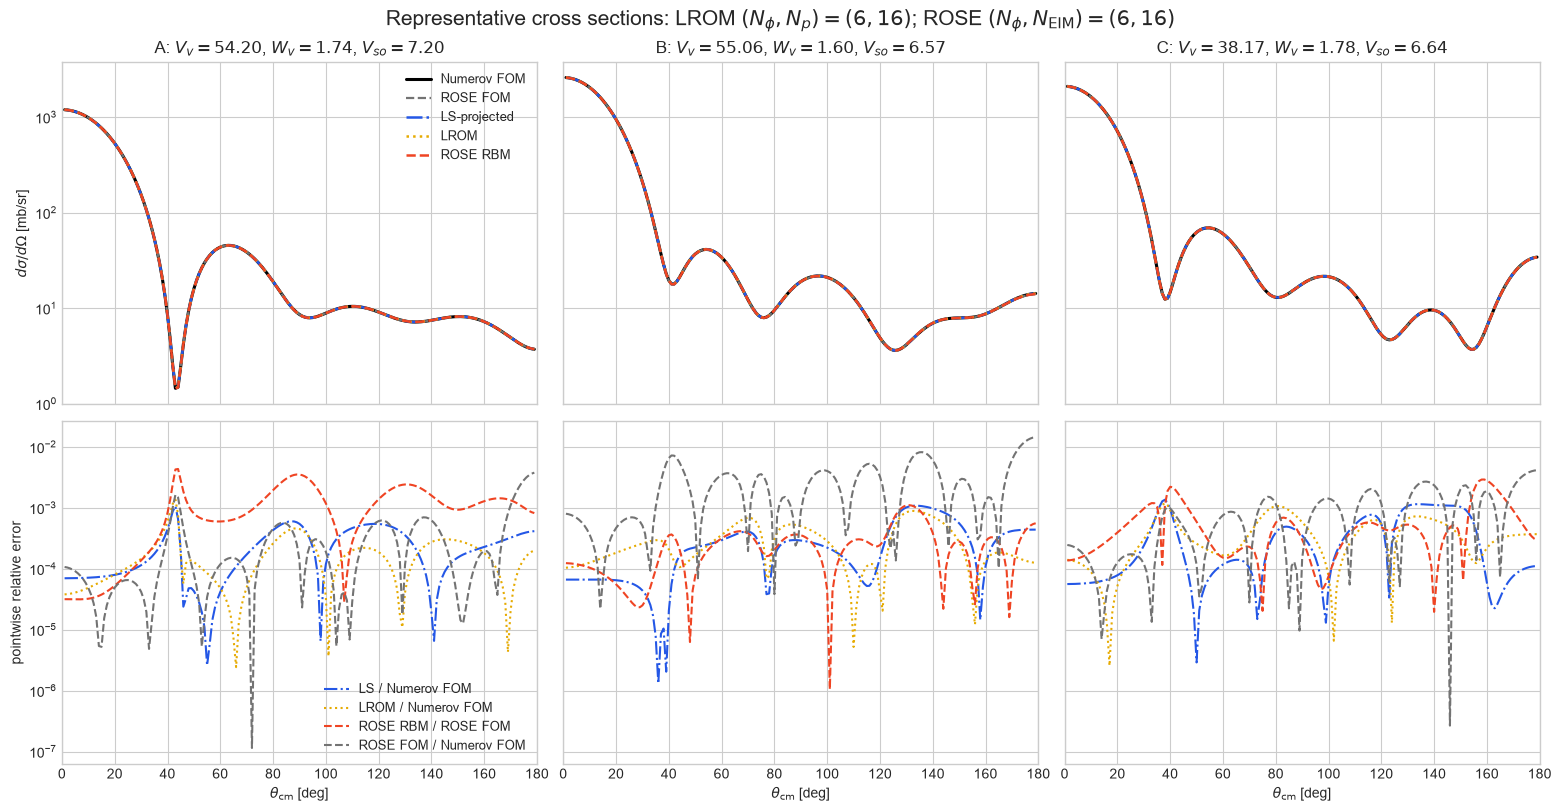

In [11]:
case_labels = ("A", "B", "C")
default = results[DEFAULT_CONFIGURATION]
fig, axes = plt.subplots(
    2, 3, figsize=(15.5, 8.0), sharex="col", sharey="row",
    layout="constrained",
)
for column, (label, index) in enumerate(zip(case_labels, selected_indices)):
    fom_curve = fom_test_xs[index]
    ls_curve = default["LS"]["test_xs"][index]
    lrom_curve = default["LROM"]["test_xs"][index]
    rose_curve = rose_representative_xs[column]
    rose_fom_curve = rose_fom_representative_xs[column]

    axes[0, column].plot(angles, fom_curve, color="black", lw=2.2,
                         label="Numerov FOM")
    axes[0, column].plot(angles, rose_fom_curve, "--", color="0.45", lw=1.6,
                         label="ROSE FOM")
    for curve, method, color, style in (
        (ls_curve, "LS-projected", COLORS["LS"], "-."),
        (lrom_curve, "LROM", COLORS["LROM"], ":"),
        (rose_curve, "ROSE RBM", COLORS["ROSE"], "--"),
    ):
        axes[0, column].plot(angles, curve, style, color=color, lw=1.8, label=method)

    for curve, reference, method, color, style in (
        (ls_curve, fom_curve, "LS / Numerov FOM", COLORS["LS"], "-."),
        (lrom_curve, fom_curve, "LROM / Numerov FOM", COLORS["LROM"], ":"),
        (rose_curve, rose_fom_curve, "ROSE RBM / ROSE FOM", COLORS["ROSE"], "--"),
        (rose_fom_curve, fom_curve, "ROSE FOM / Numerov FOM", "0.45", "--"),
    ):
        error = pointwise_relative_error(
            curve, reference,
            denominator_floor=ERROR_DENOMINATOR_FLOOR,
        )
        axes[1, column].plot(
            angles, np.maximum(error, PLOTTING_FLOOR),
            style, color=color, lw=1.5, label=method,
        )

    row = test_rows[index]
    axes[0, column].set_title(
        rf"{label}: $V_v={row[0]:.2f}$, $W_v={row[1]:.2f}$, "
        rf"$V_{{so}}={row[3]:.2f}$"
    )
    axes[0, column].set_yscale("log", nonpositive="clip")
    axes[1, column].set_yscale("log", nonpositive="clip")
    axes[0, column].yaxis.set_major_formatter(LOG_FORMATTER)
    axes[1, column].yaxis.set_major_formatter(LOG_FORMATTER)
    axes[1, column].set(xlabel=r"$\theta_{\rm cm}$ [deg]", xlim=(0, 180))

axes[0, 0].set_ylabel(r"$d\sigma/d\Omega$ [mb/sr]")
axes[1, 0].set_ylabel(r"pointwise relative error")
axes[0, 0].legend(fontsize=9)
axes[1, 0].legend(fontsize=9)
fig.suptitle(
    (r"Representative cross sections: LROM $(N_\phi,N_p)=(6,16)$; "
     r"ROSE $(N_\phi,N_{\rm EIM})=(6,16)$"),
    fontsize=15,
)
plt.show()

The gray error curve isolates the difference between the two independent
high-fidelity implementations. It includes their respective integration,
matching, and kinematic conventions. The red curve is now the genuine ROSE
reduced-model error relative to the ROSE FOM; it is no longer a second-FOM
curve mislabeled as a reduced prediction.

## 4. Computational accuracy versus time

Following the CAT definition in the ROSE paper, every point below is one
held-out optical potential with

$$
\mathrm{Accuracy}(\boldsymbol\omega)=
\max_{\theta\in[1^\circ,179^\circ]}
\left|\frac{(d\sigma/d\Omega)_{\mathrm{FOM}}-
(d\sigma/d\Omega)_{\mathrm{LROM}}}
{(d\sigma/d\Omega)_{\mathrm{FOM}}}\right|.
$$

For each reduced method, online time begins with a new optical-parameter vector and includes
evaluation of selected scaled-potential values, the small implicit solves,
reduced evaluation of $\phi(s_0)$ and $\phi'(s_0)$, $S$-matrix extraction,
and cross-section assembly. Training and FOM database construction are offline costs and are
not included. Vertical colored lines show the corresponding median online
times of the independent Numerov FOM and the reusable ROSE FOM. LROM
errors use the Numerov FOM as reference; ROSE RBM errors use the ROSE FOM.

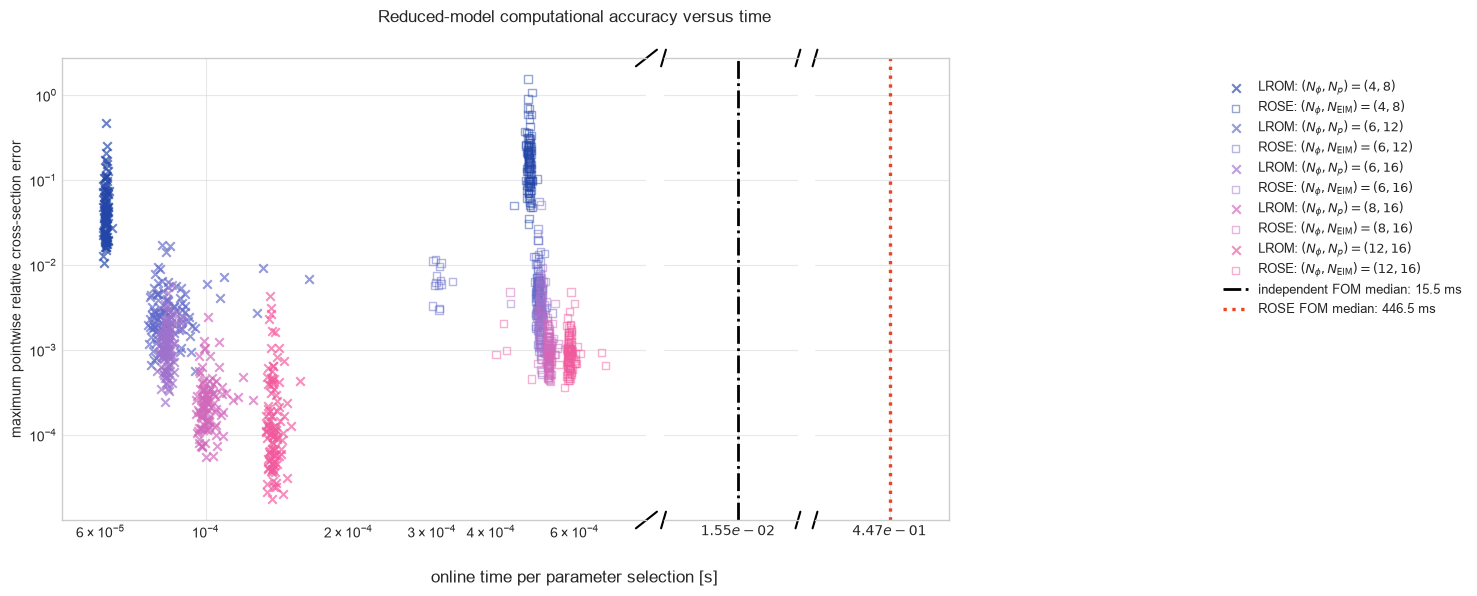

In [12]:
fig, axes = plt.subplots(
    1, 3, figsize=(12.5, 6.0), sharey=True,
    gridspec_kw={"width_ratios": [5.0, 1.15, 1.15], "wspace": 0.06},
)
ax_lrom, ax_fom, ax_rose = axes
cat_colors = PARAMETER_CMAP(np.linspace(0.0, 1.0, len(CONFIGURATIONS)))
for color, configuration in zip(cat_colors, CONFIGURATIONS):
    ax_lrom.scatter(
        results[configuration]["online_seconds"],
        np.maximum(results[configuration]["LROM"]["test_maximum_error"], PLOTTING_FLOOR),
        marker="x", s=38, alpha=0.68, color=color,
        label=rf"LROM: $(N_\phi,N_p)={configuration}$",
    )
    ax_lrom.scatter(
        rose_results[configuration]["online_seconds"],
        np.maximum(rose_results[configuration]["test_maximum_error"], PLOTTING_FLOOR),
        marker="s", s=28, alpha=0.48, facecolors="none", edgecolors=color,
        label=rf"ROSE: $(N_\phi,N_{{\rm EIM}})={configuration}$",
    )

ax_fom.axvline(
    np.median(independent_fom_seconds), color="black", linestyle="-.", lw=2.0,
    label=("independent FOM median: "
           f"{1e3 * np.median(independent_fom_seconds):.1f} ms"),
)
ax_rose.axvline(
    np.median(rose_fom_seconds), color=COLORS["ROSE"], linestyle=":", lw=2.4,
    label=f"ROSE FOM median: {1e3 * np.median(rose_fom_seconds):.1f} ms",
)
lrom_times = np.concatenate([
    results[configuration]["online_seconds"] for configuration in CONFIGURATIONS
] + [
    rose_results[configuration]["online_seconds"] for configuration in CONFIGURATIONS
])
ax_lrom.set_xlim(0.82 * lrom_times.min(), 1.22 * lrom_times.max())
fom_median = np.median(independent_fom_seconds)
rose_median = np.median(rose_fom_seconds)
ax_fom.set_xlim(0.78 * fom_median, 1.22 * fom_median)
ax_rose.set_xlim(0.78 * rose_median, 1.22 * rose_median)

for axis in axes:
    axis.set_xscale("log")
    axis.set_yscale("log", nonpositive="clip")
    axis.xaxis.set_major_formatter(LOG_FORMATTER)
    axis.yaxis.set_major_formatter(LOG_FORMATTER)
    axis.grid(True, which="major", alpha=0.45)
ax_fom.set_xticks([fom_median], [rf"${fom_median:.2e}$"])
ax_rose.set_xticks([rose_median], [rf"${rose_median:.2e}$"])
ax_fom.minorticks_off()
ax_rose.minorticks_off()
ax_lrom.set(
    ylabel="maximum pointwise relative cross-section error",
)
fig.supxlabel("online time per parameter selection [s]", y=0.02)
fig.suptitle("Reduced-model computational accuracy versus time", y=0.98)

# Diagonal marks make the two omitted time intervals explicit.
break_size = 0.018
for left_axis, right_axis in zip(axes[:-1], axes[1:]):
    left_axis.spines["right"].set_visible(False)
    right_axis.spines["left"].set_visible(False)
    right_axis.tick_params(labelleft=False, left=False)
    for y in (-break_size, 1.0 - break_size):
        left_axis.plot(
            (1.0-break_size, 1.0+break_size), (y, y+2*break_size),
            transform=left_axis.transAxes, color="black", clip_on=False,
        )
        right_axis.plot(
            (-break_size, break_size), (y, y+2*break_size),
            transform=right_axis.transAxes, color="black", clip_on=False,
        )

handles = []
labels = []
for axis in axes:
    current_handles, current_labels = axis.get_legend_handles_labels()
    handles.extend(current_handles)
    labels.extend(current_labels)
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.88), loc="upper left", fontsize=9)
fig.subplots_adjust(left=0.09, right=0.80, bottom=0.13, top=0.90)
plt.show()

<!-- RIDGE_CROSS_SECTION_EXTENSION -->
## 5. Weak ridge on exactly the same reduced model

The stability study showed that a tiny ridge can suppress poorly
identified coefficient combinations. To isolate that choice, the model
below reuses the default OLS bases, training snapshots, predictor count,
and max-volume locations. Only the regression solver changes.

In [13]:
RIDGE=1e-14
ols_default=results[DEFAULT_CONFIGURATION]["emulator"]
shared_bases={key:value.learned.basis for key,value in ols_default.channel_models.items()}
ridge_default=ScatteringLROM(
    problem,
    BasisConfig(size=DEFAULT_CONFIGURATION[0]),
    MaxVol(count=DEFAULT_CONFIGURATION[1],minimum_s=MINIMUM_PREDICTOR_S,ridge=RIDGE),
    packing_strategy="padded",
).train(training_data,precomputed_bases=shared_bases)
ridge_train_xs=ridge_default.cross_sections(train_samples,angles,linear_solver=runtime.solve)
ridge_test_xs=ridge_default.cross_sections(test_samples,angles,linear_solver=runtime.solve)
ridge_train_error=pointwise_relative_error(ridge_train_xs,fom_train_xs,denominator_floor=ERROR_DENOMINATOR_FLOOR)
ridge_test_error=pointwise_relative_error(ridge_test_xs,fom_test_xs,denominator_floor=ERROR_DENOMINATOR_FLOOR)
ols_test_error=results[DEFAULT_CONFIGURATION]["LROM"]["test_median_error"]

pd.DataFrame({
    "fit":["OLS","ridge-14"],
    "median held-out point error":[np.median(ols_test_error),np.median(ridge_test_error)],
    "95% held-out point error":[np.quantile(ols_test_error,.95),np.quantile(ridge_test_error,.95)],
    "maximum held-out point error":[np.max(ols_test_error),np.max(ridge_test_error)],
})

,fit,median held-out point error,95% held-out point error,maximum held-out point error
0,OLS,0.000209,0.000465,0.000968
1,ridge-14,0.000206,0.001059,0.005900


### Design spectrum, coefficient size, and online conditioning

A rapidly decaying snapshot spectrum is welcome; a rapidly decaying
**design-matrix** spectrum means several learned-equation coefficient
combinations have almost the same training residual. We inspect both
the offline spectrum and the condition numbers of the resulting online
matrices $A(\omega)$.

In [14]:
diagnostic_channel=(2,2.0)
learned_ols=ols_default.channel_models[diagnostic_channel].learned
coords=learned_ols.basis.project(training_data.wavefunctions[diagnostic_channel])
features=learned_ols.features(training_data.potentials[diagnostic_channel])
design=np.concatenate([np.einsum("sf,si->sfi",features,coords,optimize=True),-features[...,None]],axis=2).reshape(len(features),features.shape[1]*(coords.shape[1]+1))
spectrum=np.linalg.svd(design,compute_uv=False)
condition_rows=[]
for sample in test_samples:
    for channel in problem.channels:
        condition_rows.append((
            ols_default.predict(sample).condition_number(channel),
            ridge_default.predict(sample).condition_number(channel),
        ))
condition_rows=np.asarray(condition_rows)
coefficient_norm=lambda model: np.sqrt(sum(np.linalg.norm(v["matrices"])**2+np.linalg.norm(v["vectors"])**2 for v in model.matrices().values()))
pd.DataFrame({
    "fit":["OLS","ridge-14"],
    "coefficient norm":[coefficient_norm(ols_default),coefficient_norm(ridge_default)],
    "median condition":[np.median(condition_rows[:,0]),np.median(condition_rows[:,1])],
    "99% condition":[np.quantile(condition_rows[:,0],.99),np.quantile(condition_rows[:,1],.99)],
    "maximum condition":[condition_rows[:,0].max(),condition_rows[:,1].max()],
})

,fit,coefficient norm,median condition,99% condition,maximum condition
0,OLS,560640.412924,109.542037,8.035564e+07,1.503393e+08
1,ridge-14,2734.128168,106.277962,3.847607e+07,7.724481e+07


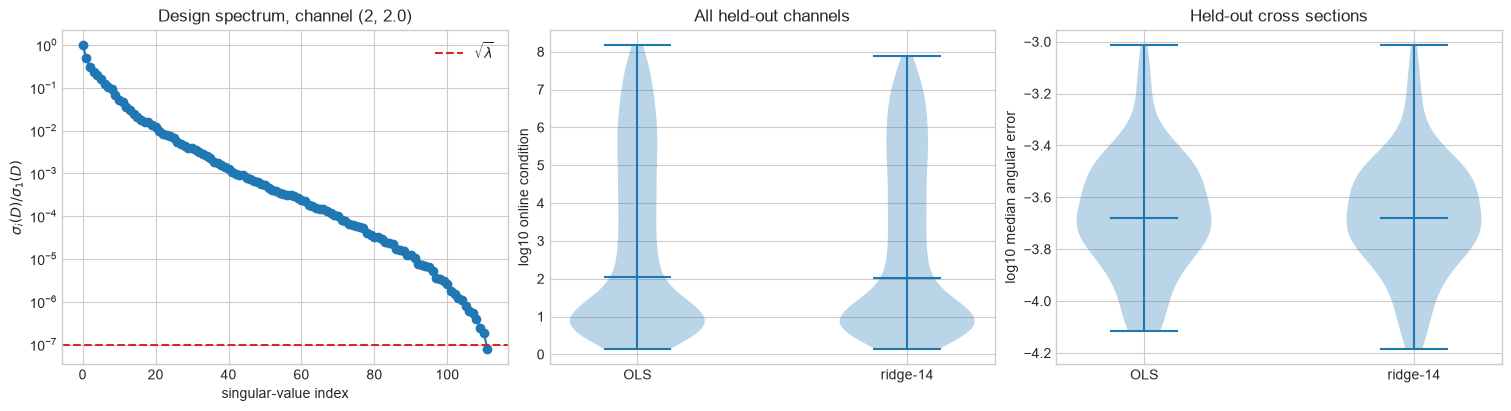

In [15]:
fig,axes=plt.subplots(1,3,figsize=(15,4),layout="constrained")
axes[0].semilogy(spectrum/spectrum[0],"o-")
axes[0].axhline(np.sqrt(RIDGE),color="tab:red",ls="--",label=r"$\sqrt{\lambda}$")
axes[0].set(xlabel="singular-value index",ylabel=r"$\sigma_i(D)/\sigma_1(D)$",title=f"Design spectrum, channel {diagnostic_channel}")
axes[0].legend()
axes[1].violinplot([np.log10(condition_rows[:,0]),np.log10(condition_rows[:,1])],showmedians=True)
axes[1].set_xticks([1,2],["OLS","ridge-14"]); axes[1].set_ylabel("log10 online condition"); axes[1].set_title("All held-out channels")
axes[2].violinplot([np.log10(np.maximum(ols_test_error,1e-14)),np.log10(np.maximum(np.median(ridge_test_error,axis=1),1e-14))],showmedians=True)
axes[2].set_xticks([1,2],["OLS","ridge-14"]); axes[2].set_ylabel("log10 median angular error"); axes[2].set_title("Held-out cross sections")
plt.show()

### Representative cross sections: OLS versus ridge

We show the ridge-best, median, and worst held-out cases according to
their median angular discrepancy. These plots are more informative than
a single aggregate score when the cross section spans many decades.

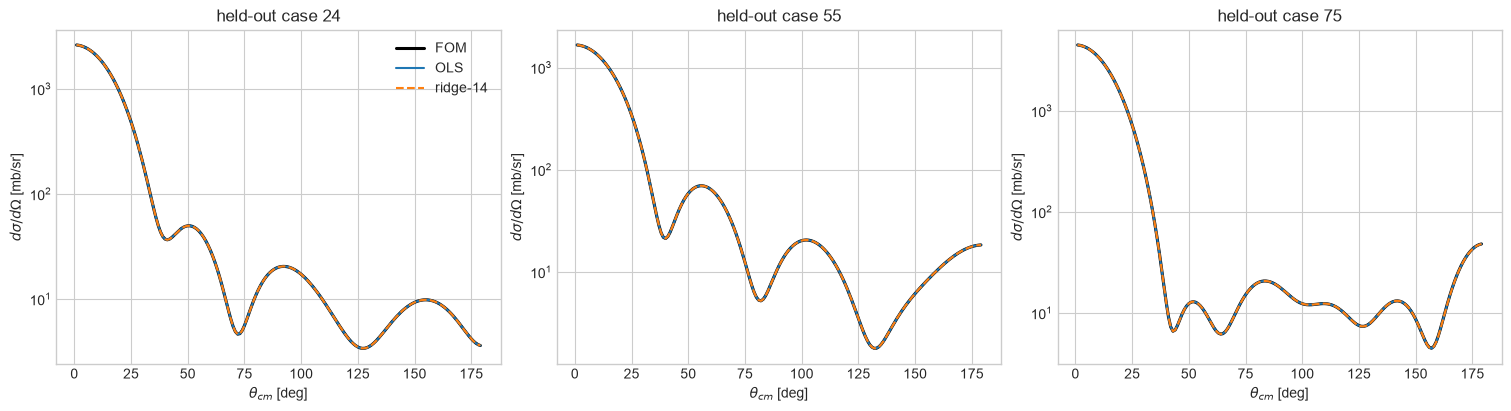

In [16]:
ridge_case_error=np.median(ridge_test_error,axis=1)
order=np.argsort(ridge_case_error)
chosen=order[[0,len(order)//2,-1]]
fig,axes=plt.subplots(1,3,figsize=(15,4),layout="constrained")
for axis,index in zip(axes,chosen):
    axis.semilogy(angles,fom_test_xs[index],color="black",lw=2.2,label="FOM")
    axis.semilogy(angles,results[DEFAULT_CONFIGURATION]["LROM"]["test_xs"][index],label="OLS")
    axis.semilogy(angles,ridge_test_xs[index],"--",label="ridge-14")
    axis.set(xlabel=r"$\theta_{cm}$ [deg]",ylabel=r"$d\sigma/d\Omega$ [mb/sr]",title=f"held-out case {index}")
axes[0].legend(); plt.show()

## 6. CPU and compiled GPU deployment

The public model is unchanged across devices. NumPy solves the stacked
reduced systems on the CPU. With `LROM_BACKEND=gpu`, JAX compiles the
batched solve and executes it on a visible GPU. Feature construction and
the angular observable remain common CPU code, which avoids maintaining
two scientific implementations.

In [17]:
cpu_runtime=get_runtime("cpu")
ridge_default.cross_sections(test_samples,angles,linear_solver=runtime.solve)
timing=[]
for label,engine in [("NumPy CPU",cpu_runtime),(runtime.name,runtime)]:
    elapsed=[]
    for _ in range(10):
        tic=time.perf_counter(); batch=ridge_default.cross_sections(test_samples,angles,linear_solver=engine.solve); elapsed.append(time.perf_counter()-tic)
    timing.append({"runtime":label,"device":engine.device,"precision":engine.precision,"batch size":len(test_samples),"best ms":1000*min(elapsed),"cross sections/s":len(test_samples)/min(elapsed)})
pd.DataFrame(timing)

,runtime,device,precision,batch size,best ms,cross sections/s
0,NumPy CPU,CPU,double,100,4.8483,20625.786300
1,numpy-cpu,CPU,double,100,4.8452,20638.982953


# Summary

The calculation separates the complete observable pipeline into clear
approximation layers. LS measures the cross-section consequences of
truncating each partial-wave basis; LROM adds the error from learning its
reduced coordinates; and independently trained ROSE RBMs provide the
Petrov--Galerkin comparison at matching basis and EIM sizes. The CAT point
clouds expose both reduced methods' online accuracy--speed trade-offs using
the same maximum-over-angle definition as the ROSE benchmark paper.

The 500-potential training database leaves every displayed implicit fit
with more than two samples per complex coefficient. The default $(6,16)$
model is motivated by the fixed-basis predictor study in Notebook 02c,
which also contains the detailed channel and coordinate diagnostics.

Energy and isotope dependence can be introduced by extending the input
vector used to generate the channel potentials. The partial-wave basis,
learned implicit equation, $S$-matrix extraction, and observable assembly
retain the same structure.